# Hyperwave Quickstart: 2x2 MMI with S-Bends

Simulate a 2x2 multimode interference coupler using gdsfactory for layout
and Hyperwave for cloud-accelerated 3D FDTD.

**What you'll learn:**
1. Convert a gdsfactory component to a simulation-ready structure
2. Set up mode sources, monitors, and absorbing boundaries
3. Run a cloud GPU simulation and analyze transmission

## Step 0: Install Dependencies

In [ ]:
%pip install -q hyperwave-community gdsfactory

## Step 1: Imports and Configuration

- `hwc.set_device()` auto-detects GPU/CPU and installs the correct JAX variant
- `hwc.set_verbose(True)` enables progress logging

In [1]:
import hyperwave_community as hwc
import gdsfactory as gf
import numpy as np
import jax.numpy as jnp

hwc.set_device("auto")
hwc.set_verbose(True)

PDK = gf.gpdk.get_generic_pdk()
PDK.activate()

RESOLUTION_UM = 0.02          # 20 nm grid spacing
N_CORE = 3.48                 # Silicon refractive index at 1550 nm
N_CLAD = 1.45                 # SiO2 cladding
WL_UM = 1.55                  # Wavelength
WG_HEIGHT_UM = 0.22           # Waveguide core height
TOTAL_HEIGHT_UM = 4.0         # Total stack height
PADDING = (100, 100, 0, 0)   # (left, right, top, bottom) in theta pixels

/home/dq4443/dev/work/hyperwave-community/.venv/lib/python3.12/site-packages/networkx/utils/backends.py:102: RuntimeWarning: networkx backend defined more than once: nx_loopback
  backends = _get_backends("networkx.backends")


## Step 2: GDS Component to Simulation Grid

- `gf.components.mmi2x2_with_sbend()` creates the photonic device layout
- `gf.c.extend_ports()` extends waveguide ports for clean mode injection
- `hwc.component_to_theta()` converts the GDS geometry to a 2D design grid

Component: extend_ports_gdsfactorypcomponentspcontainerspextension_6da1bf2d


  Theta: (3600, 500), Device: 36.0 x 5.0 um


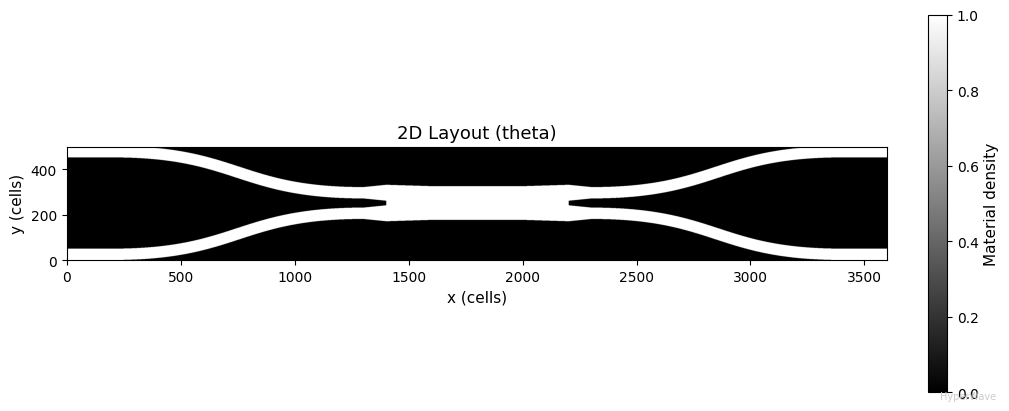

In [2]:
EXTENSION_LENGTH = 2.0        # Extend ports by 2 um

gf_device = gf.components.mmi2x2_with_sbend()
gf_extended = gf.c.extend_ports(gf_device, length=EXTENSION_LENGTH)

theta, device_info = hwc.component_to_theta(
    component=gf_extended,
    resolution=RESOLUTION_UM,
)

hwc.plot_theta(theta)

## Step 3: Build 3D Permittivity Structure

- `hwc.density()` applies density filtering for minimum feature size
- `hwc.Layer()` defines each vertical layer (cladding, core, cladding)
- `hwc.create_structure()` stacks layers into a full 3D permittivity volume

Density: (3600, 700)


Structure: 1800 x 350 x 199 = 125,370,000 cells


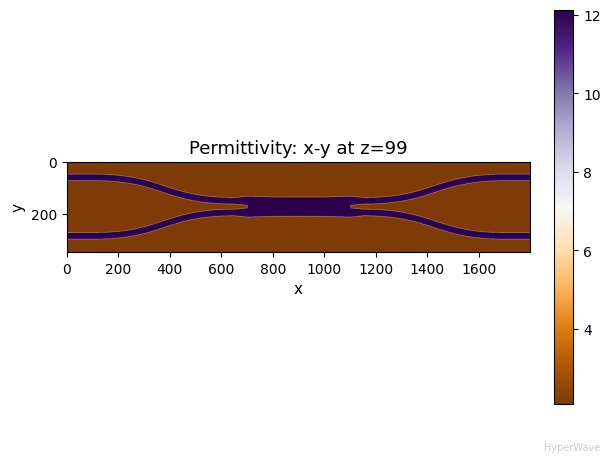

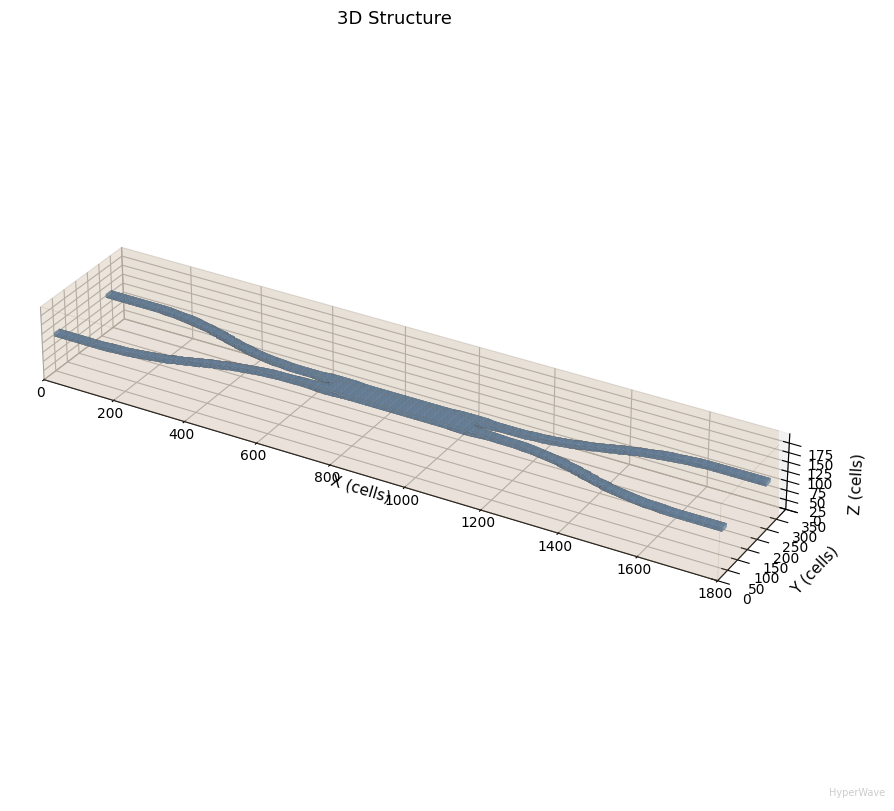

In [3]:
eps_core = N_CORE ** 2
eps_clad = N_CLAD ** 2

density_core = hwc.density(theta=theta, pad_width=PADDING, radius=3)
density_clad = hwc.density(theta=jnp.zeros_like(theta), pad_width=PADDING, radius=5)

wg_cells = max(1, int(np.round(WG_HEIGHT_UM / RESOLUTION_UM)))
clad_cells = int(np.round((TOTAL_HEIGHT_UM - WG_HEIGHT_UM) / 2 / RESOLUTION_UM))

structure = hwc.create_structure(
    layers=[
        hwc.Layer(density_pattern=density_clad, permittivity_values=eps_clad, layer_thickness=clad_cells),
        hwc.Layer(density_pattern=density_core, permittivity_values=(eps_clad, eps_core), layer_thickness=wg_cells),
        hwc.Layer(density_pattern=density_clad, permittivity_values=eps_clad, layer_thickness=clad_cells),
    ],
    vertical_radius=2,
)

z_wg_center = clad_cells + wg_cells // 2
hwc.plot_structure(structure, axis="z", position=z_wg_center)
hwc.plot_structure(structure, view_mode="3d")

## Step 4: Absorbing Boundaries (PML)

- `hwc.get_optimized_absorber_params()` returns tuned PML widths and coefficients for the grid
- `hwc.create_absorption_mask()` builds the 3D conductivity mask

Absorber: widths=(82, 41, 41), coeff=0.000617


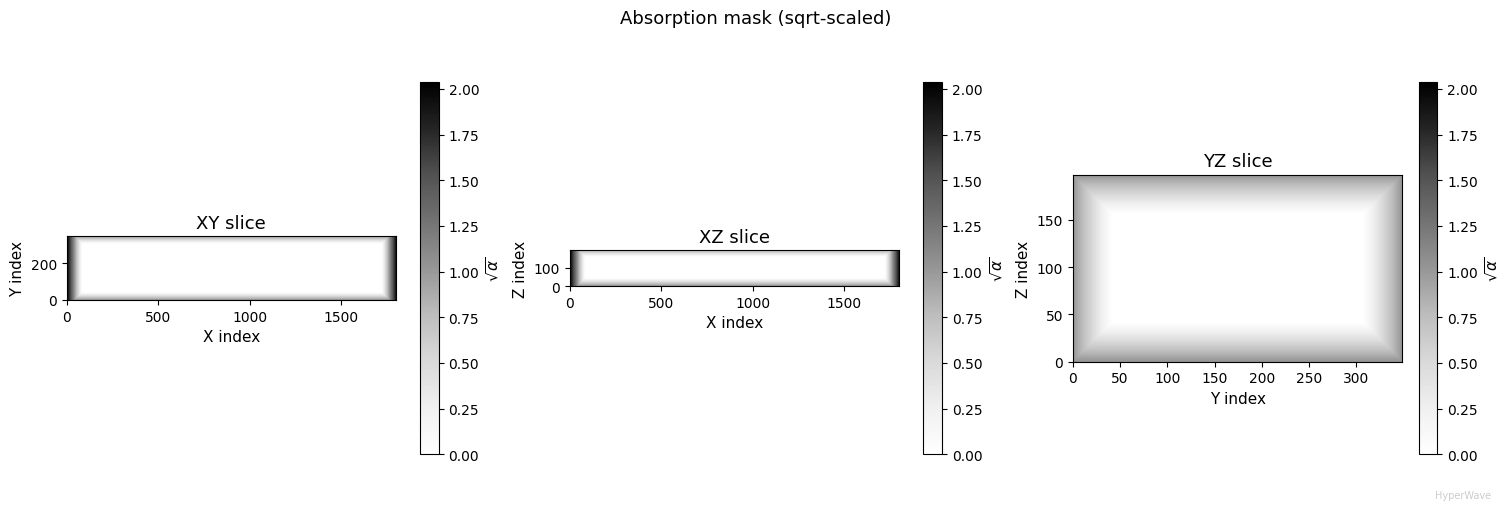

In [4]:
_, Lx, Ly, Lz = structure.permittivity.shape

abs_params = hwc.get_optimized_absorber_params(
    resolution_nm=RESOLUTION_UM * 1000,
    structure_dimensions=(Lx, Ly, Lz),
)
abs_widths = abs_params["absorption_widths"]
abs_coeff = abs_params["absorber_coeff"]

absorber = hwc.create_absorption_mask(
    grid_shape=(Lx, Ly, Lz),
    absorption_widths=abs_widths,
    absorption_coeff=abs_coeff,
)
structure.conductivity = jnp.zeros_like(structure.conductivity) + absorber

hwc.plot_absorption_mask(absorber)

## Step 5: Mode Source

- `hwc.create_mode_source()` solves for the waveguide eigenmode and creates the source field

Auto-detected waveguide at y=62 (width=24), using perpendicular_bounds=(14, 110)


Auto-detected z_core=99, using z_bounds=(51, 147)


Source: shape=(1, 6, 1, 96, 96), offset=(82, 14, 51), beta=[0.19948572]


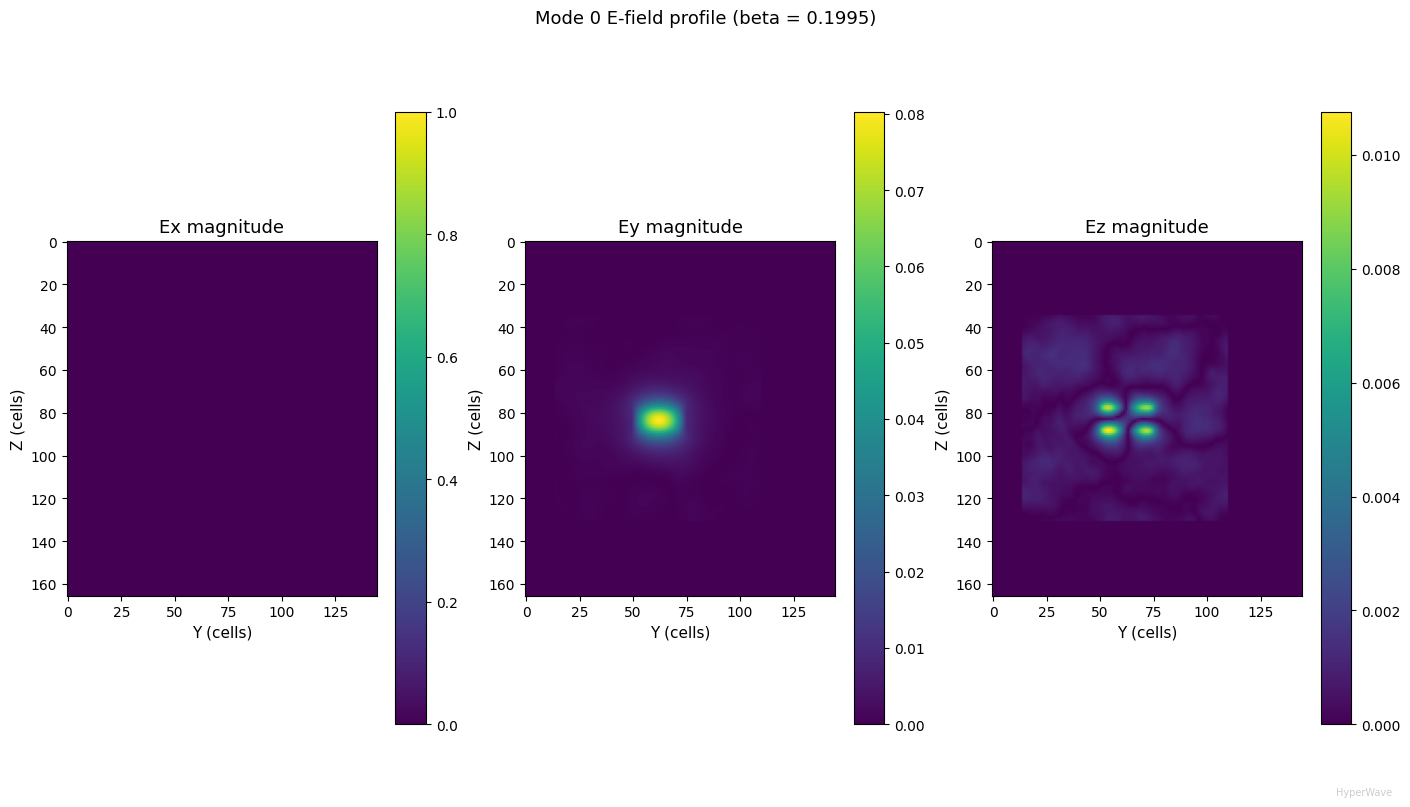

In [5]:
wl_cells = WL_UM / RESOLUTION_UM
freq_band = (2 * jnp.pi / wl_cells, 2 * jnp.pi / wl_cells, 1)

source_field, source_offset, mode_info = hwc.create_mode_source(
    structure=structure,
    freq_band=freq_band,
    mode_num=0,
    propagation_axis="x",
    source_position=abs_widths[0],
)

hwc.plot_mode(
    mode_field=mode_info["field"],
    beta=mode_info["beta"],
    mode_num=0,
    propagation_axis="x",
)

## Step 6: Port Monitors

- `hwc.create_port_monitors()` auto-detects waveguide ports from the GDS component and places monitors

Auto-detected z_wg_center=96


Monitor added: Input_o1 (shape=(5, 70, 70), offset=(100, 27, 61))


Monitor added: Output_o4 (shape=(5, 70, 70), offset=(1700, 27, 61))


Monitor added: Input_o2 (shape=(5, 70, 70), offset=(100, 252, 61))


Monitor added: Output_o3 (shape=(5, 70, 70), offset=(1700, 252, 61))


Monitor added: xy_mid (shape=(1800, 350, 1), offset=(0, 0, 96))


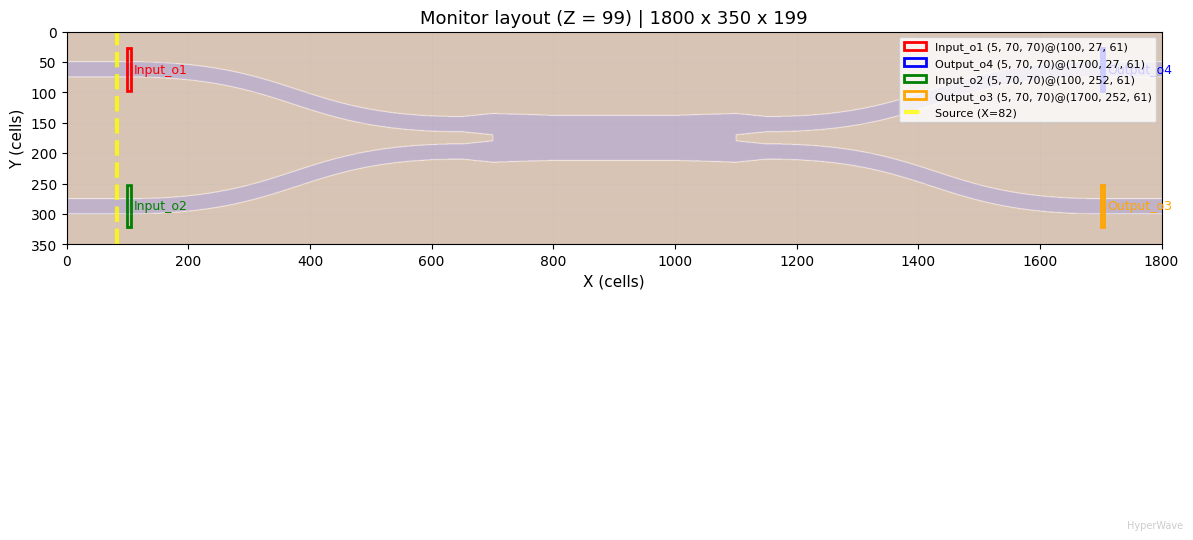

In [6]:
monitors = hwc.create_port_monitors(
    component=gf_device,
    structure=structure,
    device_info=device_info,
    padding=PADDING,
    absorption_widths=abs_widths,
)

hwc.plot_monitor_layout(
    structure.permittivity, monitors,
    axis="z", position=z_wg_center, source_position=abs_widths[0],
)

## Step 7: Run Simulation

- `hwc.configure_api()` sets the API key (auto-detects Colab secrets or env vars)
- `hwc.simulate()` sends the simulation to the cloud GPU and streams results back
- `hwc.save_results()` / `hwc.load_results()` for caching results locally

In [ ]:
# To skip simulation and load saved results:
# results = hwc.load_results("quickstart_results.npz")

try:
    from google.colab import userdata
    hwc.configure_api(api_key=userdata.get("HYPERWAVE_API_KEY"))
except ImportError:
    import os
    hwc.configure_api(api_key=os.environ.get("HYPERWAVE_API_KEY"))

results = hwc.simulate(
    structure_recipe=structure.extract_recipe(),
    source_field=source_field,
    source_offset=source_offset,
    freq_band=freq_band,
    monitors_recipe=monitors.recipe,
    mode_info=mode_info,
    simulation_steps=20000,
    absorption_widths=abs_widths,
    absorption_coeff=abs_coeff,
)

hwc.save_results(results, "quickstart_results.npz")

## Step 8: Analyze Results

- `hwc.analyze_transmission()` computes S-parameters from the monitor data
- `hwc.plot_monitors()` visualizes field snapshots at each monitor

Transmission Analysis (Input: Input_o1)


  Output_o4             T = 0.4806  (-3.18 dB)


  Output_o3             T = 0.4674  (-3.30 dB)


  Total                 T = 0.9480  (-0.23 dB)


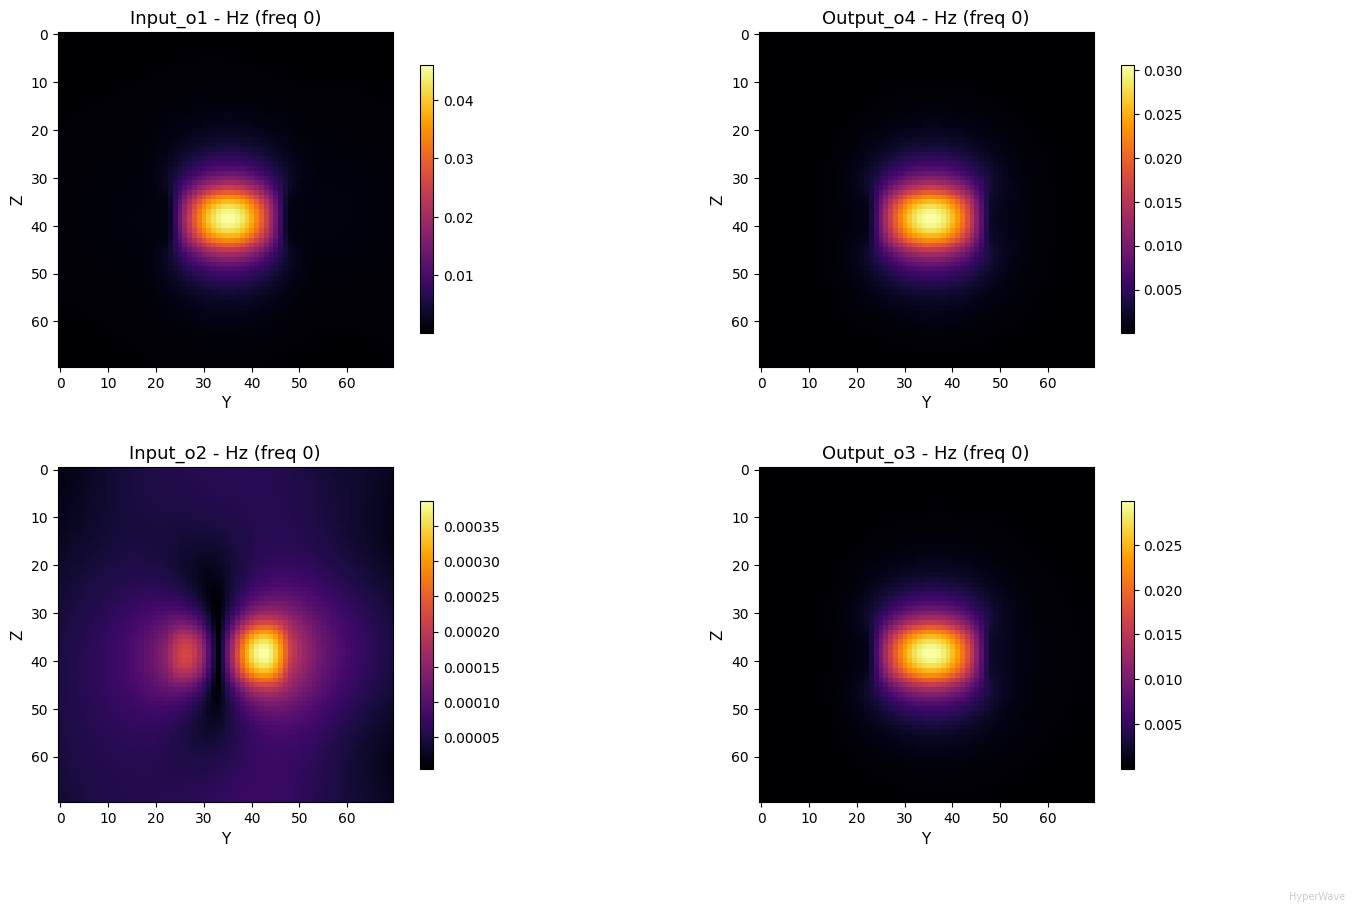

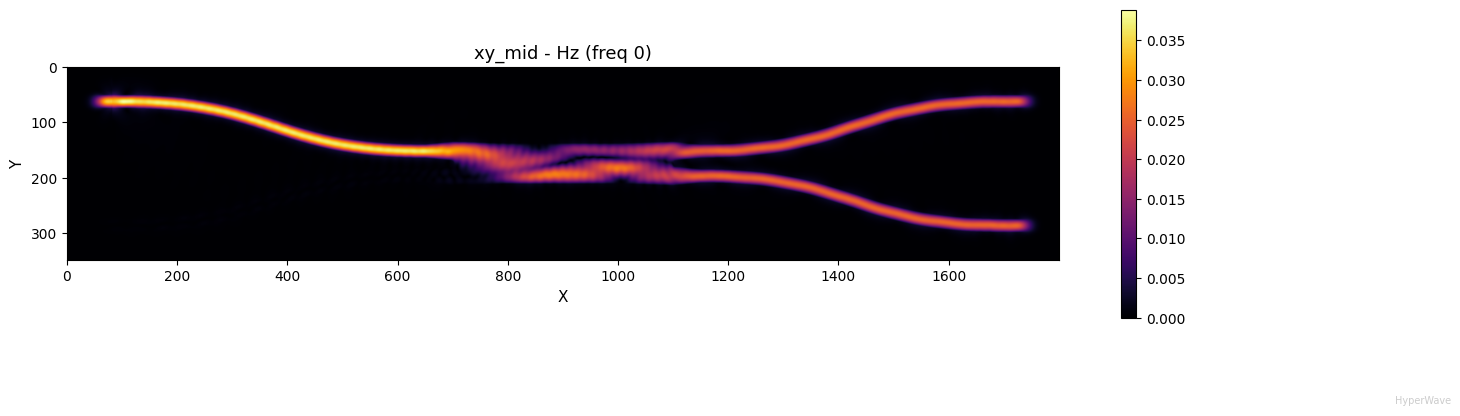

In [8]:
transmission = hwc.analyze_transmission(
    results, input_monitor="Input_o1", direction="x",
)

hwc.plot_monitors(results, component="Hz")